### Importing

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram , linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

### Loading Data

In [ ]:
dataframe = pd.read_csv("Customer_segmentation.csv")
dataframe.head()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1


### EDA

In [124]:
dataframe.shape

(2000, 8)

In [125]:
dataframe.columns

Index(['ID', 'Sex', 'Marital status', 'Age', 'Education', 'Income',
       'Occupation', 'Settlement size'],
      dtype='object')

In [126]:
dataframe.duplicated().sum()

np.int64(0)

In [127]:
dataframe.isnull().sum()

ID                 0
Sex                0
Marital status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement size    0
dtype: int64

In [128]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB


In [129]:
dataframe.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2000.0,1.000010e+08,577.494589,100000001.0,1.000005e+08,100001000.5,1.000015e+08,100002000.0
Sex,2000.0,4.570000e-01,0.498272,0.0,0.000000e+00,0.0,1.000000e+00,1.0
Marital status,2000.0,4.965000e-01,0.500113,0.0,0.000000e+00,0.0,1.000000e+00,1.0
Age,2000.0,3.590900e+01,11.719402,18.0,2.700000e+01,33.0,4.200000e+01,76.0
Education,2000.0,1.038000e+00,0.599780,0.0,1.000000e+00,1.0,1.000000e+00,3.0
Income,2000.0,1.209544e+05,38108.824679,35832.0,9.766325e+04,115548.5,1.380722e+05,309364.0
Occupation,2000.0,8.105000e-01,0.638587,0.0,0.000000e+00,1.0,1.000000e+00,2.0
Settlement size,2000.0,7.390000e-01,0.812533,0.0,0.000000e+00,1.0,1.000000e+00,2.0


In [130]:
dataframe = dataframe.drop(columns = ["ID"])

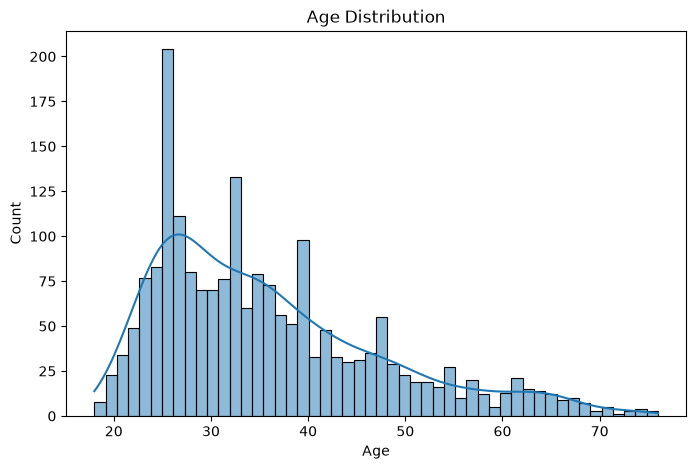

In [131]:
plt.figure(figsize = (8 , 5))
sns.histplot(dataframe["Age"] , bins = 50 , kde = True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

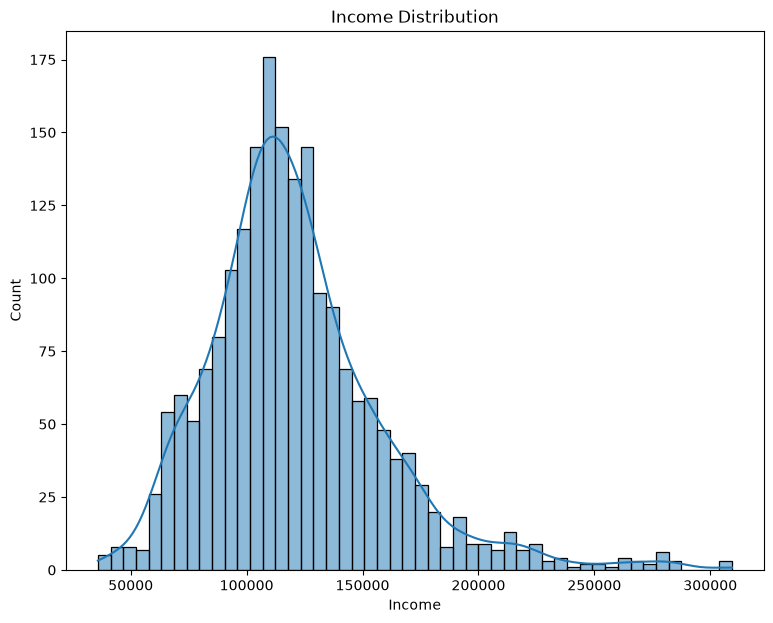

In [132]:
plt.figure(figsize = (9 , 7))
sns.histplot(dataframe["Income"] , bins = 50 , kde = True)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

### Preprocessing Data

In [133]:
scaler = StandardScaler()
df = scaler.fit_transform(dataframe)
data = pd.DataFrame(df , columns = dataframe.columns)

### Dendrogram

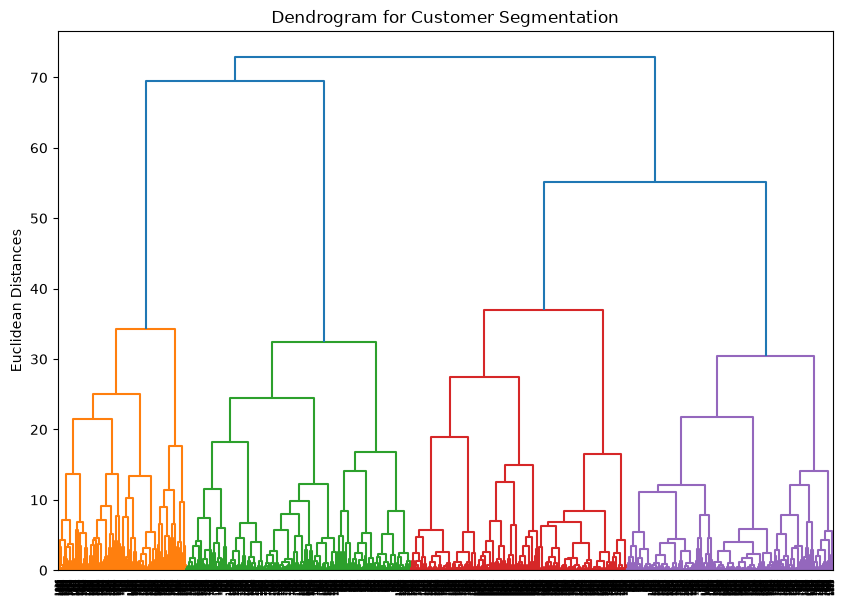

In [139]:
plt.figure(figsize = (10 , 7))
dendrogram(linkage(data , method = "ward") , orientation = "top" , distance_sort = "descending" , show_leaf_counts = True)

plt.title("Dendrogram for Customer Segmentation")
plt.ylabel("Euclidean Distances")
plt.show()

### Model Training & Prediction & Evaluation

In [140]:
model = AgglomerativeClustering(n_clusters = 2 , linkage = "ward" , metric = "euclidean")
result = model.fit_predict(data)

In [141]:
data["Result"] = result

In [143]:
data.head()

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Result
0,-0.917399,-0.993024,2.653614,1.604323,0.097524,0.296823,1.552326,0
1,1.090038,1.007025,-1.187132,-0.063372,0.782654,0.296823,1.552326,1
2,-0.917399,-0.993024,1.117316,-0.063372,-0.833202,-1.269525,-0.909730,1
3,-0.917399,-0.993024,0.775916,-0.063372,1.328386,0.296823,0.321298,0
4,-0.917399,-0.993024,1.458716,-0.063372,0.736932,0.296823,0.321298,0


In [142]:
print(f"Silhouette Score : {silhouette_score(data , result)}")

Silhouette Score : 0.23630477516993512
